# **🚧 Automated Road Damage Classification**
## ╰┈➤ Project: Pothole, Crack, and Manhole Detection

**Dataset**
- **Class 0:** Pothole
- **Class 1:** Crack
- **Class 2:** Manhole

In [42]:
# Data processing
import pandas as pd
import numpy as np

# File handling
import os
import shutil
import random
from pathlib import Path
import cv2


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator as KerasImageDataGenerator

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models , optimizers # model architecture
from tensorflow.keras.applications import ResNet50 
from tensorflow.keras.applications import MobileNetV2     # transfer learning model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator # data augmentation

# Model evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score


# Hide warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
print("TF version:", tf.__version__)

TF version: 2.20.0


In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

#  **Data Load**

In [ ]:
DATA_DIR = r"D:\Intern Project\Final Project\data"
IMAGES_DIR = os.path.join(DATA_DIR, "images")
LABELS_DIR = os.path.join(DATA_DIR, "labels")
OUTPUT_DIR = r"D:\Intern Project\Final Project\split_dataset_fixed"

CLASS_MAP = {
    0: "0_pothole",
    1: "1_crack",
    2: "2_manhole"}

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# **Create folders**

In [5]:
def get_classes_from_label(label_path):
    classes = set()
    if not os.path.exists(label_path):
        return classes
    
    with open(label_path, "r") as f:
       
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) > 0:
                class_id = int(parts[0])
                if class_id in CLASS_MAP:
                    classes.add(CLASS_MAP[class_id])
    return classes

In [6]:
def create_dirs():
    splits = ["train", "validation", "test"]
    for split in splits:
        for class_name in CLASS_MAP.values():
            dir_path = os.path.join(OUTPUT_DIR, split, class_name)
            os.makedirs(dir_path, exist_ok=True)
    print("Output directories created!")

create_dirs()

Output directories created!


# **Split Images into Train / Validation / Test**

In [7]:
# Get all image files
all_images = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
random.shuffle(all_images)

# Calculate split sizes
total_imgs = len(all_images)
train_end = int(total_imgs * TRAIN_RATIO)
val_end = train_end + int(total_imgs * VAL_RATIO)

train_imgs = all_images[:train_end]
val_imgs = all_images[train_end:val_end]
test_imgs = all_images[val_end:]

print(f"Total images: {total_imgs}")
print(f"Train: {len(train_imgs)}, Validation: {len(val_imgs)}, Test: {len(test_imgs)}")

Total images: 2009
Train: 1406, Validation: 301, Test: 302


In [8]:
# Function to copy images to respective directories based on their labels
def process_split(image_set, split_name):
    copied_count = 0
    for img_name in image_set:
        img_path = os.path.join(IMAGES_DIR, img_name)
        
        # The label file has the same name as the image but with .txt extension
        base_name = os.path.splitext(img_name)[0]
        label_name = base_name + ".txt"
        label_path = os.path.join(LABELS_DIR, label_name)

        # Get classes present in the image
        classes = get_classes_from_label(label_path)
        
        # Copy the image to the respective class folders
        for class_name in classes:
            dest_path = os.path.join(OUTPUT_DIR, split_name, class_name, img_name)
            shutil.copy2(img_path, dest_path)
            copied_count += 1
            
    print(f"Copied {copied_count} files into {split_name} directories.")

# **Final summary**

In [9]:
print("Processing Train split...")
process_split(train_imgs, "train")

print("\nProcessing Validation split...")
process_split(val_imgs, "validation")

print("\nProcessing Test split...")
process_split(test_imgs, "test")

print("\nData splitting is complete! ")

Processing Train split...
Copied 2070 files into train directories.

Processing Validation split...
Copied 433 files into validation directories.

Processing Test split...
Copied 426 files into test directories.

Data splitting is complete! 


In [10]:
TRAIN_DIR = os.path.join(OUTPUT_DIR, "train")
VAL_DIR = os.path.join(OUTPUT_DIR, "validation")
TEST_DIR = os.path.join(OUTPUT_DIR, "test")

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Validation exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))

Train exists: True
Validation exists: True
Test exists: True


In [11]:
for folder in os.listdir(TRAIN_DIR):
    folder_path = os.path.join(TRAIN_DIR, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)), "images")

0_pothole : 709 images
1_crack : 1238 images
2_manhole : 683 images


# **Data Preprocessed steps :**

### **Load Images and Apply Resizing**
The `target_size` parameter automatically resizes all images to `224x224`.

In [12]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

In [13]:
train_ds = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_ds = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_ds.class_indices)
print(train_ds.class_indices)

Found 2630 images belonging to 3 classes.
Found 685 images belonging to 3 classes.
Found 681 images belonging to 3 classes.
{'0_pothole': 0, '1_crack': 1, '2_manhole': 2}


# **Handle the class Balanced (or) Imbalanced**

In [14]:
class_names = list(train_ds.class_indices.keys())
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

Classes: ['0_pothole', '1_crack', '2_manhole']


In [15]:
counts = np.bincount(train_ds.classes)
print(dict(zip(class_names, counts)))

{'0_pothole': np.int64(709), '1_crack': np.int64(1238), '2_manhole': np.int64(683)}


In [16]:
early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-6)

## **1) . CNN Model**

In [17]:
baseline_model = models.Sequential([
    
    layers.Input(shape=(224,224,3)),
    
    layers.Conv2D(32,3,activation="relu",padding="same"),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64,3,activation="relu",padding="same"),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128,3,activation="relu",padding="same"),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.4),
    
    layers.Dense(NUM_CLASSES,activation="softmax")
])

In [18]:
baseline_model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,819 (49.36 MB)

 Trainable params: 12,938,819 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_baseline = baseline_model.fit(
    train_ds,validation_data=val_ds,epochs=15,callbacks=[early_stop,reduce_lr])

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.4529 - loss: 1.1936 - val_accuracy: 0.4949 - val_loss: 1.0491 - learning_rate: 0.0010
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 128s 2s/step - accuracy: 0.4707 - loss: 1.0617 - val_accuracy: 0.4949 - val_loss: 1.0420 - learning_rate: 0.0010
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.4715 - loss: 1.0604 - val_accuracy: 0.4949 - val_loss: 1.0324 - learning_rate: 0.0010
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.4711 - loss: 1.0584 - val_accuracy: 0.4949 - val_loss: 1.0291 - learning_rate: 0.0010
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - accuracy: 0.4707 - loss: 1.0555 - val_accuracy: 0.4949 - val_loss: 1.0298 - learning_rate: 0.0010
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.4711 - loss: 1.0533 - val_accuracy: 0.4949 - val_loss: 1.0214 - learning_rate: 0.0010
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.4707 - loss: 1.0547 - val_acc

In [20]:
test_loss, test_accuracy =baseline_model.evaluate(test_ds)
print(" Baseline Model Evaluation Results")
print("-" * 30 )
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Final Accuracy Score: {test_accuracy*100:.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 371ms/step - accuracy: 0.4949 - loss: 1.0128
 Baseline Model Evaluation Results
------------------------------
Test Loss    : 1.0128
Test Accuracy: 0.4949
Final Accuracy Score: 49.49%


In [36]:
class_names = ['0_Pothole', '1_Crack', '2_Manhole']
# Generate classification report as dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
# Convert to DataFrame
df = pd.DataFrame(report).T
print("🟦 DARK BLUE  : High Value (Model performs well in this class)")
print("🟪 LIGHT BLUE : Low Value  (Model performance needs improvement)")
print("-" * 30)
# Styled Table
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)
display(styled_table)

🟦 DARK BLUE  : High Value (Model performs well in this class)
🟪 LIGHT BLUE : Low Value  (Model performance needs improvement)
------------------------------


,precision,recall,f1-score,support
0_Pothole,0.52,0.08,0.14,171.00
1_Crack,0.49,0.97,0.66,332.00
2_Manhole,0.00,0.00,0.00,178.00
accuracy,0.49,0.49,0.49,0.49
macro avg,0.34,0.35,0.27,681.00
weighted avg,0.37,0.49,0.35,681.00


# **2) . Transfer learning using pre-trained models**

### **MobileNetV2 MODEL and RESNET50 MODEL**

# **i ) .  MobileNetV2 MODEL**

In [23]:
# 1. Load pretrained base model
base_mobilenet = MobileNetV2(weights="imagenet",include_top=False,input_shape=(224,224,3))

In [24]:
base_mobilenet.trainable = False

In [25]:
mobilenet_model = models.Sequential([
    
    layers.Input(shape=(224,224,3)),
    
    layers.Lambda(lambda x: x*2.0 - 1.0),
    
    base_mobilenet,
    
    layers.GlobalAveragePooling2D(),
    
    layers.BatchNormalization(),
    
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.4),
    
    layers.Dense(NUM_CLASSES,activation="softmax")
])

In [26]:
# 4. Compile
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss="categorical_crossentropy",metrics=["accuracy"])

In [27]:
history_mobilenet = mobilenet_model.fit(train_ds,validation_data=val_ds,epochs=15,callbacks=[early_stop,reduce_lr])

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.4175 - loss: 1.6270 - val_accuracy: 0.5212 - val_loss: 0.9952 - learning_rate: 0.0010
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.4688 - loss: 1.3281 - val_accuracy: 0.5358 - val_loss: 1.0040 - learning_rate: 0.0010
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.4966 - loss: 1.1641 - val_accuracy: 0.5650 - val_loss: 0.9214 - learning_rate: 0.0010
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.5034 - loss: 1.0983 - val_accuracy: 0.5693 - val_loss: 0.9551 - learning_rate: 0.0010
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.5323 - loss: 1.0155 - val_accuracy: 0.5781 - val_loss: 0.8988 - learning_rate: 0.0010
Epoch 6/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.5452 - loss: 0.9766 - val_accuracy: 0.6015 - val_loss: 0.8602 - learning_rate: 0.0010
Epoch 7/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.5460 - loss: 0.9607 - val_acc

In [28]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)
print("MobileNetV2 Evaluation Results")
print("-" * 30)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Final Accuracy Score: {test_accuracy*100:.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 928ms/step - accuracy: 0.6167 - loss: 0.8192
MobileNetV2 Evaluation Results
------------------------------
Test Loss    : 0.8192
Test Accuracy: 0.6167
Final Accuracy Score: 61.67%


In [29]:
# Fine-tuning
base_mobilenet.trainable = True

In [30]:
for layer in base_mobilenet.layers[:-30]:
    layer.trainable = False

In [31]:
for layer in base_mobilenet.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [32]:
# Recompile with low LR
mobilenet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
fine_tune_early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
fine_tune_reduce_lr = ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=2,min_lr=1e-7,verbose=1)

In [52]:
history_mobilenet_finetune = mobilenet_model.fit(
    train_ds,validation_data=val_ds,epochs=10,callbacks=[fine_tune_early_stop, fine_tune_reduce_lr])

Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5890 - loss: 0.8729 - val_accuracy: 0.6248 - val_loss: 0.8325 - learning_rate: 1.0000e-05
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.5943 - loss: 0.8678 - val_accuracy: 0.6292 - val_loss: 0.8225 - learning_rate: 1.0000e-05
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.6015 - loss: 0.8466 - val_accuracy: 0.6409 - val_loss: 0.8055 - learning_rate: 1.0000e-05
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6057 - loss: 0.8478 - val_accuracy: 0.6584 - val_loss: 0.7906 - learning_rate: 1.0000e-05
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.5897 - loss: 0.8530 - val_accuracy: 0.6613 - val_loss: 0.7893 - learning_rate: 1.0000e-05
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.5939 - loss: 0.8479 - val_accuracy: 0.6526 - val_loss: 0.7851 - learning_rate: 1.0000e-05
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.5848 

In [53]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_ds)

print("\n--- MobileNetV2 Fine-Tuned Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")
print(f"Final Accuracy Score: {test_accuracy*100:.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6535 - loss: 0.7814

--- MobileNetV2 Fine-Tuned Results ---
----------------------------------------

Test Loss        : 0.7814

Test Accuracy    : 0.6535

Final Accuracy Score: 65.35%


In [54]:
y_true = test_ds.classes

y_pred_probs = mobilenet_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

print("-"*30)
print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"F1-score  : {f1_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print("-"*30)

22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 949ms/step
------------------------------
Accuracy  : 0.6535
Precision : 0.6488
Recall    : 0.5817
F1-score  : 0.5892
------------------------------


In [55]:
class_names = ['0_Pothole', '1_Crack', '2_Manhole']
# Generate classification report as dictionary
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
# Convert to DataFrame
df = pd.DataFrame(report).T
print("🟦 DARK BLUE  : High Value (Model performs well in this class)")
print("🟪 LIGHT BLUE : Low Value  (Model performance is weak in this class)")
print("-" * 55)
# Styled Table
styled_table = df.style.background_gradient(cmap='Blues').format(precision=2)
display(styled_table)

🟦 DARK BLUE  : High Value (Model performs well in this class)
🟪 LIGHT BLUE : Low Value  (Model performance is weak in this class)
-------------------------------------------------------


,precision,recall,f1-score,support
0_Pothole,0.59,0.29,0.39,171.00
1_Crack,0.65,0.89,0.75,332.00
2_Manhole,0.71,0.57,0.63,178.00
accuracy,0.65,0.65,0.65,0.65
macro avg,0.65,0.58,0.59,681.00
weighted avg,0.65,0.65,0.63,681.00


#  **ii ) . Pre-trained  (ResNet50 Model)**

In [56]:
base_resnet = ResNet50(weights="imagenet",include_top=False,input_shape=(224,224,3))

base_resnet.trainable = False

In [57]:
resnet_model = models.Sequential([
    
    layers.Input(shape=(224,224,3)),
    
    layers.Lambda(lambda x: tf.keras.applications.resnet50.preprocess_input(x*255.0)),
    
    base_resnet,
    
    layers.GlobalAveragePooling2D(),
    
    layers.BatchNormalization(),
    
    layers.Dense(256,activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(NUM_CLASSES,activation="softmax")])

In [59]:
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(0.0005),loss="categorical_crossentropy",metrics=["accuracy"])

In [60]:
history_resnet = resnet_model.fit(train_ds,validation_data=val_ds,epochs=15,callbacks=[early_stop,reduce_lr])

Epoch 1/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 306s 4s/step - accuracy: 0.4278 - loss: 1.6292 - val_accuracy: 0.4511 - val_loss: 1.1248 - learning_rate: 5.0000e-04
Epoch 2/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 293s 4s/step - accuracy: 0.4555 - loss: 1.4330 - val_accuracy: 0.5270 - val_loss: 1.0692 - learning_rate: 5.0000e-04
Epoch 3/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 293s 4s/step - accuracy: 0.4833 - loss: 1.2994 - val_accuracy: 0.5869 - val_loss: 0.9256 - learning_rate: 2.5000e-04
Epoch 4/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 295s 4s/step - accuracy: 0.4954 - loss: 1.2171 - val_accuracy: 0.6073 - val_loss: 0.9190 - learning_rate: 2.5000e-04
Epoch 5/15
83/83 ━━━━━━━━━━━━━━━━━━━━ 291s 4s/step - accuracy: 0.5068 - loss: 1.1433 - val_accuracy: 0.6088 - val_loss: 0.8984 - learning_rate: 1.2500e-04


In [61]:
base_resnet.trainable = True

In [62]:
for layer in base_resnet.layers[:-30]:
    layer.trainable = False

In [ ]:
resnet_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),loss="categorical_crossentropy",metrics=["accuracy"])

In [66]:
history_resnet_finetune = resnet_model.fit(
    train_ds,validation_data=val_ds,epochs=20,callbacks=[fine_tune_early_stop, fine_tune_reduce_lr])

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 448s 5s/step - accuracy: 0.4437 - loss: 1.4628 - val_accuracy: 0.5416 - val_loss: 0.9921 - learning_rate: 1.0000e-05
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.4755 - loss: 1.3782
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
83/83 ━━━━━━━━━━━━━━━━━━━━ 442s 5s/step - accuracy: 0.4540 - loss: 1.4085 - val_accuracy: 0.5737 - val_loss: 0.9810 - learning_rate: 1.0000e-05
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 456s 5s/step - accuracy: 0.4791 - loss: 1.3292 - val_accuracy: 0.5810 - val_loss: 0.9916 - learning_rate: 5.0000e-06
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4767 - loss: 1.3322
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
83/83 ━━━━━━━━━━━━━━━━━━━━ 426s 5s/step - accuracy: 0.4681 - loss: 1.3319 - val_accuracy: 0.5752 - val_loss: 0.9877 - learning_rate: 5.0000e-06
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 448s 5s/step - accuracy: 0.4840 - loss: 1.2819

In [68]:
test_loss, test_accuracy = resnet_model.evaluate(test_ds)

print("\n--- ResNet50 Fine-Tuned Results ---")
print("-" * 40 + "\n")
print(f"Test Loss        : {test_loss:.4f}\n")
print(f"Test Accuracy    : {test_accuracy:.4f}\n")
print(f"Final Accuracy Score: {test_accuracy*100:.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 89s 4s/step - accuracy: 0.5257 - loss: 1.0274

--- ResNet50 Fine-Tuned Results ---
----------------------------------------

Test Loss        : 1.0274

Test Accuracy    : 0.5257

Final Accuracy Score: 52.57%


In [69]:
mobilenet_model.save("mobilenetv2_finetuned.h5")
resnet_model.save("resnet50_finetuned.h5")
print("Models saved successfully!")

Models saved successfully!


In [ ]:
# 1. Models Summary Data
models = [
    (baseline_model, "Baseline CNN"),
    (mobilenet_model, "MobileNetV2 FT"),
    (resnet_model, "ResNet50 FT")
]

# 2. Collect Metrics (Short Loop)
metrics = []
for model, name in models:
    y_pred = np.argmax(model.predict(test_ds, verbose=0), axis=1)
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    
    metrics.append({
        "Model": name,
        "Accuracy": rep["accuracy"],
        "Precision_macro": rep["macro avg"]["precision"],
        "Recall_macro": rep["macro avg"]["recall"],
        "F1_macro": rep["macro avg"]["f1-score"]
    })

# 3. Final Table & Best Model
df_final = pd.DataFrame(metrics).sort_values("F1_macro", ascending=False)
display(df_final)

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro
1,MobileNetV2 FT,0.653451,0.648757,0.581709,0.589153
2,ResNet50 FT,0.525698,0.512217,0.483885,0.489185
0,Baseline CNN,0.494860,0.337467,0.351588,0.265529


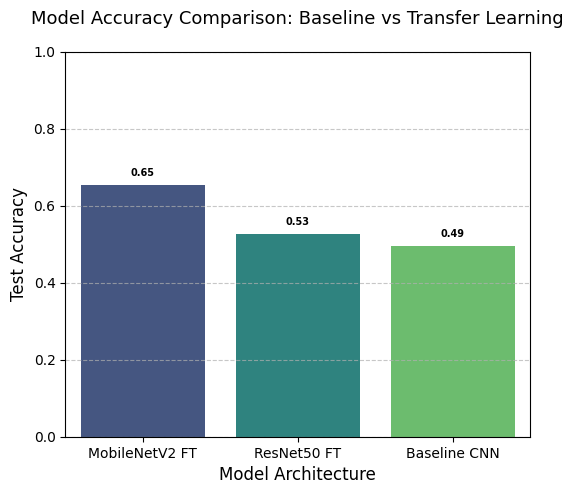

In [71]:
plt.figure(figsize=(6, 5))
bars = sns.barplot(x="Model", y="Accuracy", data=df_final, 
                   palette="viridis", hue="Model", legend=False)

for p in bars.patches:
    bars.annotate(f'{p.get_height():.2f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=7, fontweight='bold')


plt.title('Model Accuracy Comparison: Baseline vs Transfer Learning', fontsize=13, pad=20)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylim(0, 1.0) # Accuracy range 0 to 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()